# Titanic — Machine Learning from Disaster
---
## 1 · Imports & Data Loading

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.patches import Patch

train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

test_passenger_ids = test_df['PassengerId']

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')

Train: (891, 12)  |  Test: (418, 11)


---
## 2 · Feature Engineering

In [276]:
# Merge train + test so preprocessing is identical for both
full_df = pd.concat(
    [train_df.drop('Survived', axis=1), test_df],
    axis=0, sort=False
).reset_index(drop=True)

# --- 1. Title ---
# Extract title from Name, normalise variants, group rare ones, encode as integer
full_df['Title'] = full_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
full_df['Title'] = full_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
full_df['Title'] = full_df['Title'].replace('Mme', 'Mrs')
rare_titles = ['Dr','Rev','Col','Major','Don','Lady','Sir','Capt','Countess','Jonkheer','Dona']
full_df['Title'] = full_df['Title'].replace(rare_titles, 'Rare')
title_mapping = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5}
full_df['Title'] = full_df['Title'].map(title_mapping).fillna(0)

# --- 2. Family features ---
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1
full_df['IsAlone']    = (full_df['FamilySize'] == 1).astype(int)

# --- 3. HasCabin — 1 if cabin number is known, else 0 ---
full_df['HasCabin'] = full_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# --- 4. Embarked — fill 2 missing values with the mode ---
full_df['Embarked'] = full_df['Embarked'].fillna(full_df['Embarked'].mode()[0])

# --- 5. Sex → binary integer ---
full_df['Sex'] = full_df['Sex'].map({'male': 0, 'female': 1}).astype(int)

# --- 6. Age — impute with median per Pclass × Sex group ---
full_df['Age'] = full_df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# --- 7. Fare — impute 1 missing test value with Pclass median ---
full_df['Fare'] = full_df.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# --- 8. Embarked one-hot encoding ---
full_df = pd.get_dummies(full_df, columns=['Embarked'], drop_first=True)

# --- 9. FarePerPerson — fare split across the travelling group ---
full_df['FarePerPerson'] = full_df['Fare'] / full_df['FamilySize']

# --- 10. Drop columns that don't add signal ---
full_df = full_df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])

print('Preprocessing complete. Shape:', full_df.shape)
full_df.head()

Preprocessing complete. Shape: (1309, 13)


,Pclass,Sex,Age,SibSp,Parch,Fare,Title,FamilySize,IsAlone,HasCabin,Embarked_Q,Embarked_S,FarePerPerson
0,3,0,22.0,1,0,7.2500,1,2,0,0,False,True,3.62500
1,1,1,38.0,1,0,71.2833,3,2,0,1,False,False,35.64165
2,3,1,26.0,0,0,7.9250,2,1,1,0,False,True,7.92500
3,1,1,35.0,1,0,53.1000,3,2,0,1,False,True,26.55000
4,3,0,35.0,0,0,8.0500,1,1,1,0,False,True,8.05000


---
## 3 · Prepare Train / Test Sets

In [277]:
# Split back into train and test
X      = full_df.iloc[:len(train_df)]
X_test = full_df.iloc[len(train_df):]
y      = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale required for LR - KNN - SVM
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_sc       = scaler.fit_transform(X)      
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  Val: {X_val_sc.shape}  Test: {X_test_sc.shape}')

Train: (712, 13)  Val: (179, 13)  Test: (418, 13)


---
## 4 · Model Comparison

In [278]:
# models
models = {
    'Random Forest' : RandomForestClassifier(
                                  n_estimators=700, max_depth=5,
                                  min_samples_leaf=3, min_samples_split=2,
                                  random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingClassifier(
                                  n_estimators=200, max_depth=3,
                                  learning_rate=0.05, random_state=42),
    'Logistic Regression'   : LogisticRegression(C=0.5, max_iter=1000, random_state=42),
    'KNN'                   : KNeighborsClassifier(n_neighbors=7),
    'SVM'                   : SVC(kernel='rbf', C=1.0, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=4, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_sc))
    cv      = cross_val_score(model, X_sc, y, cv=5, scoring='accuracy', n_jobs=-1)
    results.append({
        'Model'       : name,
        'Val Accuracy': round(val_acc, 4),
        'CV Mean'     : round(cv.mean(), 4),
        'CV Std'      : round(cv.std(),  4),
    })
    print(f'{name:<26} | Val: {val_acc:.4f} | CV: {cv.mean():.4f} ± {cv.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV Mean', ascending=False)
print('\n')
print(results_df.to_string(index=False))

Random Forest              | Val: 0.7989 | CV: 0.8238 ± 0.0110
Gradient Boosting          | Val: 0.7877 | CV: 0.8317 ± 0.0141
Logistic Regression        | Val: 0.7989 | CV: 0.8126 ± 0.0131
KNN                        | Val: 0.7877 | CV: 0.7935 ± 0.0189
SVM                        | Val: 0.8212 | CV: 0.8271 ± 0.0213
Decision Tree              | Val: 0.8212 | CV: 0.8215 ± 0.0206


              Model  Val Accuracy  CV Mean  CV Std
  Gradient Boosting        0.7877   0.8317  0.0141
                SVM        0.8212   0.8271  0.0213
      Random Forest        0.7989   0.8238  0.0110
      Decision Tree        0.8212   0.8215  0.0206
Logistic Regression        0.7989   0.8126  0.0131
                KNN        0.7877   0.7935  0.0189


---
## 5 · Final Model — Tuned Random Forest


In [279]:
# model that scored 0.79186 on Kaggle
final_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=5,
    min_samples_leaf=6,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)

# Fit on ALL training data
final_model.fit(X_sc, y)

cv_final = cross_val_score(final_model, X_sc, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Train accuracy : {final_model.score(X_sc, y):.4f}  (biased — model has seen all data)')
print(f'CV accuracy    : {cv_final.mean():.4f} ± {cv_final.std():.4f}  (honest estimate)')

Train accuracy : 0.8496  (biased — model has seen all data)
CV accuracy    : 0.8249 ± 0.0089  (honest estimate)


---
## 6 · Feature Importance Plot

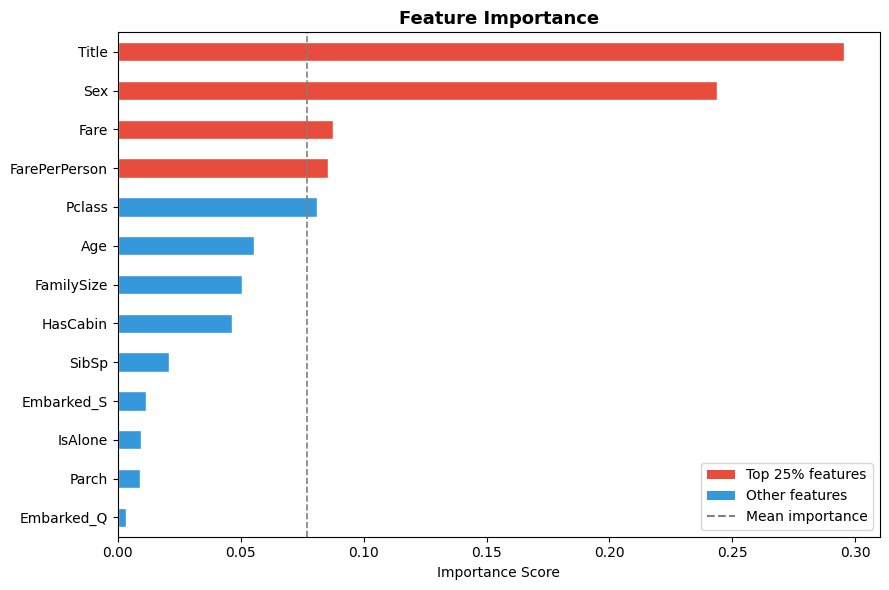


Top 5 most important features:
Title            0.295261
Sex              0.243911
Fare             0.087374
FarePerPerson    0.085500
Pclass           0.081025
dtype: float64


In [280]:
importances = final_model.feature_importances_
feat_names  = X.columns
fi          = pd.Series(importances, index=feat_names).sort_values(ascending=True)

# Highlight the top-25% features in red
threshold = fi.quantile(0.75)
colors    = ['#e74c3c' if v >= threshold else '#3498db' for v in fi.values]

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.axvline(fi.mean(), color='grey', linestyle='--', linewidth=1.2)
ax.set_title('Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

legend_handles = [
    Patch(facecolor='#e74c3c', label='Top 25% features'),
    Patch(facecolor='#3498db', label='Other features'),
    plt.Line2D([0], [0], color='grey', linestyle='--', label='Mean importance'),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(fi.sort_values(ascending=False).head())

---
## 7 · Generate Submission File

In [281]:
predictions = final_model.predict(X_test_sc).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived':    predictions
})

submission.to_csv('../data/submission.csv', index=False)

print(f'Predicted survivors : {predictions.sum()} / {len(predictions)}')
print(f'Survival rate       : {predictions.mean():.2%}')
submission.head(10)

Predicted survivors : 157 / 418
Survival rate       : 37.56%


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
